In [ ]:
# Importing important libraries
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn import svm
from joblib import parallel_backend
import matplotlib.pyplot as plt
import random

---
MNIST dataset is fetched from OpenML and used the first 7,000 elements of the dataset.

Then data is splitted into test and train sets. Train set has 5,600 data and test set has 1,400 data.

In [ ]:
# Loading MNIST dataset from OpenML
mnist = fetch_openml(name='mnist_784', version=1)
data_lim = 10000

# Splitting data into train and test sets by 0.8 for given limit
X_train, X_test, y_train, y_test = train_test_split(
    mnist.data.values[:data_lim], mnist.target.values[:data_lim], test_size=0.2, random_state=27)

# Printing the dimensions of dataset in given limit
print("Dimension of Numbers:", mnist.data[:data_lim].shape)
print("Dimension of Labels:", mnist.target[:data_lim].shape)

Dimension of Numbers: (10000, 784)
Dimension of Labels: (10000,)


---
Randomly 8 elements are chosen from the dataset and their images and labels are visualized.

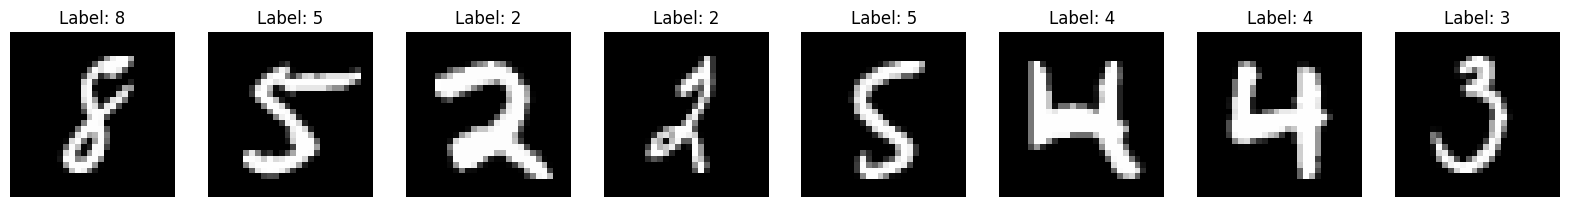

In [ ]:
# Visualization of data in 8 example
fig, axes = plt.subplots(1, 8, figsize=(20,5))

for i in range(8):
  random_i = random.randint(0, len(X_train))
  ax = axes[i]
  ax.imshow(X_train[random_i].reshape(28,28), cmap="gray")
  ax.set_title(f"Label: {y_train[random_i]}")
  ax.axis('off')

plt.show()

---
SVC model is called and the model is trained using parallel backend (from joblib library) with using all the possible processors.

- 'loky' attribute is specifies the parallel backend base.
- n_jobs=-1 means that joblib tries all the CPUs to use.

Then 5-Fold Cross Validation used to the baseline model also using all the possible processors.

In the next codeline, all the accuracies for cross validation, minimum accuracy and, maximum accuracy are printed.

In [ ]:
# Training SVC model using all processors with multiprocessing
svc_model = svm.SVC()

with parallel_backend('loky', n_jobs=-1):
  svc_model.fit(X_train, y_train)

# Using 5-Fold Cross Validation in baseline model and fitting by using all processors with multiprocessing
cross_val_5 = cross_val_score(svc_model, X_train, y_train, cv=5, n_jobs=-1)

In [ ]:
# Printing the results of 5-Fold Cross Validation model
print(f"Accuracy Scores in 5-Fold Cross-Validation: {cross_val_5}")
print(f"Minimum Accuracy Score in 5-Fold Cross Validation: {cross_val_5.min()}")
print(f"Maximum Accuracy Score in 5-Fold Cross Validation: {cross_val_5.max()}")

Accuracy Scores in 5-Fold Cross-Validation: [0.96     0.9475   0.968125 0.951875 0.95875 ]
Minimum Accuracy Score in 5-Fold Cross Validation: 0.9475
Maximum Accuracy Score in 5-Fold Cross Validation: 0.968125


---
Hyperparameter ranges are defined in a dictionary then randomized search are used with these ranges in 10 iterations. Randomized search is also trained with parallel backend to use all the possible processors.

Then in the next codeline, the best hyperparameters and accuracy based on the best hyperparameters are printed out.

In [ ]:
# Defining hyperparameter ranges
random_prm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['linear', 'rbf', 'poly']
}

# Using Random Search with hyperparameter ranges and fitting by using all processors with multiprocessing
random_search = RandomizedSearchCV(svc_model, random_prm, n_iter=10, cv=5)

with parallel_backend('loky', n_jobs=-1):
  random_search.fit(X_train, y_train)

In [ ]:
# Printing the best hyperparameters and accuracy for that parameters
print(f"Best Hyperparameters: {random_search.best_params_}")
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)
print(f"Accuracy for found best model {best_random_model}: {accuracy_score(y_test, y_pred_random)}")

Best Hyperparameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 100}
Accuracy for found best model SVC(C=100): 0.966


---
A narrower range of hyperparameter are defined for grid search.

- For 'C' values; corresponding best value is used from random search, along with values scaled by a factor of 1/10 and 10, are used to explore a smaller range.
- For 'gamma' and 'kernel' values; corresponding best values are used directly from the random search.

Then grid search is applied also trained with parallel backend to use all the possible processors.

Then in the next codeline, the best hyperparameters and accuracy based on the best hyperparameters are printed out.

In [ ]:
# Defining a narrower hyperparameter range
grid_prm = {
    'C': [best_random_model.C / 10, best_random_model.C, best_random_model.C * 10],
    'gamma': [best_random_model.gamma],
    'kernel': [best_random_model.kernel]
}

# Using Grid Search with narrowed hyperparameter ranges and fitting by using all processors with multiprocessing
grid_search = GridSearchCV(svc_model, grid_prm, cv=5)

with parallel_backend('loky', n_jobs=-1):
  grid_search.fit(X_train, y_train)

In [ ]:
# Printing the best hyperparameters and accuracy for that parameters
print(f"Best Hyperparameters: {grid_search.best_params_}")
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test)
print(f"Accuracy for found best model {best_grid_model}: {accuracy_score(y_test, y_pred_grid)}")

Best Hyperparameters: {'C': 10.0, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy for found best model SVC(C=10.0): 0.966


---
All accuracies of previous models are printed out in one line.

In [ ]:
accuracies = [accuracy_score(y_test, svc_model.predict(X_test)),
              accuracy_score(y_test, y_pred_random),
              accuracy_score(y_test, y_pred_grid)]

# Printing the accuracies of each model
print("Accuracy of Baseline Model:", accuracies[0])
print("Accuracy of Randomized Search:", accuracies[1])
print("Accuracy of Grid Search:", accuracies[2])

Accuracy of Baseline Model: 0.956
Accuracy of Randomized Search: 0.966
Accuracy of Grid Search: 0.966


---
To see the difference clearly a bar chart is provided to all the accuracies.

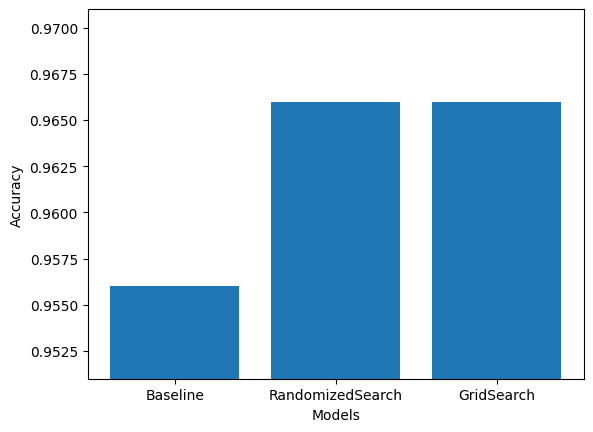

In [ ]:
models = ["Baseline", "RandomizedSearch", "GridSearch"]
y_min = min(accuracies)-0.005
y_max = max(accuracies)+0.005

# Visualization of each accuracy in a bar plot
plt.bar(models, accuracies)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(y_min, y_max)
plt.show()

---
Confusion matrix are printed out to see how accurate the model predicted the values.

- The x-axis values are the models prediction.
- The y-axis values are the actual values.
- The main diagonal of matrix shows the correctly predicted values for each class.

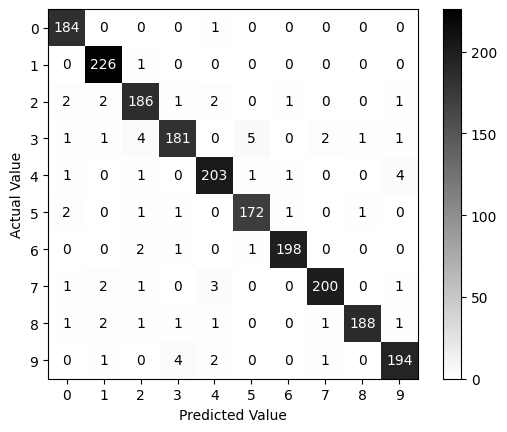

In [ ]:
# Finding and visualization of the confusion matrix
predictions = [svc_model.predict(X_test), y_pred_random, y_pred_grid]

best_pred = predictions[accuracies.index(max(accuracies))]

conf_m = confusion_matrix(y_test, best_pred, labels=svc_model.classes_)

conf_plot = ConfusionMatrixDisplay(conf_m, display_labels=svc_model.classes_).plot(cmap="binary")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

Based on the bar charts and the confusion matrix, we can conclude that our model demonstrates very high accuracy in classifying the MNIST dataset.

The accuracies achieved using RandomizedSearchCV and GridSearchCV are very close to each other because both methods explore approximately the same set of hyperparameters. However, the baseline model's accuracy is also close to these optimized models. The maximum accuracy achieved is 0.966 with both GridSearchCV and RandomizedSearchCV, while the minimum accuracy is 0.956 with the baseline model. This indicates that hyperparameter tuning has successfully improved the overall accuracy of our model.

---
<h2>Burak Demirci</h2>
<h3>2201292</h3>